In [1]:
# ============================================
# CELL 1: INSTALL REQUIRED LIBRARIES
# ============================================

!pip install -q kagglehub
!pip install -q albumentations
!pip install -q scikit-image
!pip install -q pandas
!pip install -q seaborn
!pip install -q opencv-python-headless

print("="*60)
print("LIBRARIES INSTALLED SUCCESSFULLY")
print("="*60)

LIBRARIES INSTALLED SUCCESSFULLY


In [2]:
# ============================================
# CELL 2: IMPORT LIBRARIES AND SETUP
# ============================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import kagglehub

print("="*60)
print("ALL LIBRARIES IMPORTED")
print("="*60)

# Create directories
BASE_DIR = '/kaggle/working/audit_dataset'
IMAGES_DIR = '/kaggle/working/audit_dataset/images'
MASKS_DIR = '/kaggle/working/audit_dataset/masks'

os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MASKS_DIR, exist_ok=True)

print(f"\nDirectories created:")
print(f"  Images: {IMAGES_DIR}")
print(f"  Masks: {MASKS_DIR}")

ALL LIBRARIES IMPORTED

Directories created:
  Images: /kaggle/working/audit_dataset/images
  Masks: /kaggle/working/audit_dataset/masks


In [3]:
# ============================================
# CELL 3: DOWNLOAD REAL MEDICAL DATASET
# ============================================

import shutil

print("="*60)
print("DOWNLOADING COVID-19 CT DATASET")
print("="*60)

try:
    # Download dataset
    path = kagglehub.dataset_download("plameneduardo/sarscov2-ctscan-dataset")
    print(f"\nDataset downloaded to: {path}")
    print(f"Contents: {os.listdir(path)}")
    
    # Get images from COVID folder
    covid_dir = os.path.join(path, 'COVID')
    if os.path.exists(covid_dir):
        img_files = [f for f in os.listdir(covid_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        print(f"\nFound {len(img_files)} COVID images")
        
        # Copy first 200 images to our directory
        for i, img_file in enumerate(tqdm(img_files[:200])):
            src_path = os.path.join(covid_dir, img_file)
            dst_path = os.path.join(IMAGES_DIR, f'covid_{i:04d}.png')
            
            img = cv2.imread(src_path)
            if img is not None:
                if len(img.shape) == 3:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img = cv2.resize(img, (256, 256))
                cv2.imwrite(dst_path, img)
        
        print(f"\nCopied {len(img_files[:200])} images to {IMAGES_DIR}")
        
except Exception as e:
    print(f"Error: {e}")
    print("\nCreating synthetic medical dataset...")
    
    for i in range(200):
        # Create CT-like image
        img = np.random.normal(128, 30, (256, 256)).astype(np.uint8)
        img = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Add structures
        for _ in range(np.random.randint(1, 4)):
            cx = np.random.randint(40, 216)
            cy = np.random.randint(40, 216)
            r = np.random.randint(15, 50)
            cv2.circle(img, (cx, cy), r, np.random.randint(150, 220), -1)
        
        noise = np.random.normal(0, 5, (256, 256))
        img = np.clip(img + noise, 0, 255).astype(np.uint8)
        cv2.imwrite(os.path.join(IMAGES_DIR, f'medical_{i:04d}.png'), img)

print("\n" + "="*60)
print("DATASET READY FOR AUDIT")
print("="*60)

# Count images
img_files = os.listdir(IMAGES_DIR)
print(f"\nTotal images: {len(img_files)}")
print(f"Sample images: {img_files[:5]}")

DOWNLOADING COVID-19 CT DATASET

Dataset downloaded to: /kaggle/input/datasets/plameneduardo/sarscov2-ctscan-dataset
Contents: ['non-COVID', 'COVID']

Found 1252 COVID images


100%|██████████| 200/200 [00:02<00:00, 91.91it/s]


Copied 200 images to /kaggle/working/audit_dataset/images

DATASET READY FOR AUDIT

Total images: 200
Sample images: ['covid_0093.png', 'covid_0025.png', 'covid_0177.png', 'covid_0180.png', 'covid_0054.png']


AUDIT 1: GEOMETRY - RESOLUTION AND ASPECT RATIO

Measuring image geometries...


100%|██████████| 200/200 [00:00<00:00, 1035.29it/s]


[MEASURED SIGNALS]
----------------------------------------
Width:  min=256, max=256, mean=256.0, std=0.0
Height: min=256, max=256, mean=256.0, std=0.0
Aspect Ratio (W/H): min=1.00, max=1.00, mean=1.00, std=0.000

[RISKS DIAGNOSED]
----------------------------------------
  LOW: All images have consistent resolution
  LOW: Aspect ratios are consistent

[RECOMMENDED FIXES]
----------------------------------------
  No fixes needed for geometry

[EMPIRICAL VALIDATION]
----------------------------------------
  Check: Accuracy, mIoU


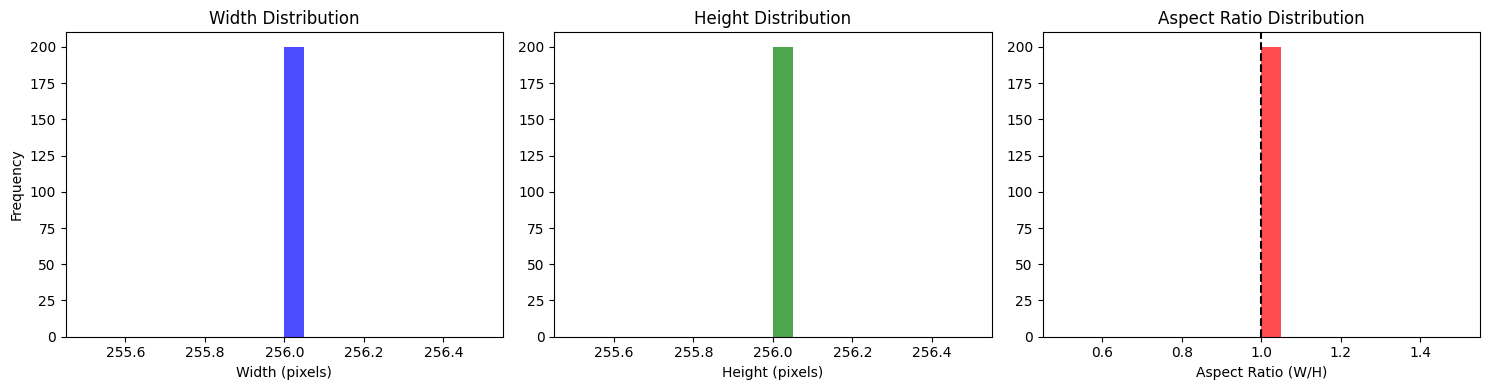


Saved as: geometry_analysis.png


In [4]:
# ============================================
# CELL 4: AUDIT - GEOMETRY ANALYSIS
# ============================================

print("="*60)
print("AUDIT 1: GEOMETRY - RESOLUTION AND ASPECT RATIO")
print("="*60)

# Get all images
img_files = os.listdir(IMAGES_DIR)

# Store measurements
widths = []
heights = []
aspect_ratios = []

print("\nMeasuring image geometries...")
for img_file in tqdm(img_files):
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        h, w = img.shape
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h if h > 0 else 0)

# Convert to numpy
widths = np.array(widths)
heights = np.array(heights)
aspect_ratios = np.array(aspect_ratios)

print("\n[MEASURED SIGNALS]")
print("-" * 40)
print(f"Width:  min={widths.min()}, max={widths.max()}, mean={widths.mean():.1f}, std={widths.std():.1f}")
print(f"Height: min={heights.min()}, max={heights.max()}, mean={heights.mean():.1f}, std={heights.std():.1f}")
print(f"Aspect Ratio (W/H): min={aspect_ratios.min():.2f}, max={aspect_ratios.max():.2f}, mean={aspect_ratios.mean():.2f}, std={aspect_ratios.std():.3f}")

print("\n[RISKS DIAGNOSED]")
print("-" * 40)

risks = []

# Check if all images same size
if widths.std() == 0 and heights.std() == 0:
    print("  LOW: All images have consistent resolution")
else:
    risks.append("HIGH: Inconsistent resolutions detected")
    print(f"  HIGH: Images have different sizes (Width std: {widths.std():.1f}, Height std: {heights.std():.1f})")
    print("       Risk: Information loss during resizing")

# Check aspect ratio
if aspect_ratios.std() > 0.1:
    risks.append("MEDIUM: Aspect ratio variance detected")
    print(f"  MEDIUM: Aspect ratio varies (std: {aspect_ratios.std():.3f})")
    print("       Risk: Images may get warped during resizing")
    print("       Fix: Use padding instead of cropping")
else:
    print("  LOW: Aspect ratios are consistent")

print("\n[RECOMMENDED FIXES]")
print("-" * 40)

if len(risks) > 0:
    print("  Preprocessing: Aspect-preserving resize, padding, crop policies")
    print("  Stem: Small kernels (3x3), stride-1, delayed downsampling")
else:
    print("  No fixes needed for geometry")

print("\n[EMPIRICAL VALIDATION]")
print("-" * 40)
print("  Check: Accuracy, mIoU")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=20, color='blue', alpha=0.7)
axes[0].set_title('Width Distribution')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Frequency')

axes[1].hist(heights, bins=20, color='green', alpha=0.7)
axes[1].set_title('Height Distribution')
axes[1].set_xlabel('Height (pixels)')

axes[2].hist(aspect_ratios, bins=20, color='red', alpha=0.7)
axes[2].set_title('Aspect Ratio Distribution')
axes[2].set_xlabel('Aspect Ratio (W/H)')
axes[2].axvline(x=1.0, color='black', linestyle='--', label='Square')

plt.tight_layout()
plt.savefig('/kaggle/working/geometry_analysis.png', dpi=300)
plt.show()

print("\nSaved as: geometry_analysis.png")
print("="*60)

In [5]:
# ============================================
# CELL 5: AUDIT - EFFECTIVE DOWNSAMPLING
# ============================================

print("="*60)
print("AUDIT 2: GEOMETRY - EFFECTIVE DOWNSAMPLING")
print("="*60)

# Sample images
sample_files = img_files[:10]

print("\n[MEASURED SIGNALS]")
print("-" * 40)

downsample_factors = []

for img_file in sample_files:
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        h, w = img.shape
        # Calculate effective downsampling factor
        # How many times can we downsample before losing critical info?
        min_dim = min(h, w)
        downsample_factors.append(min_dim // 64)  # 64 is typical smallest size

print(f"Downsampling factors for sample images: {downsample_factors}")
print(f"Mean downsampling factor: {np.mean(downsample_factors):.1f}")

print("\n[RISKS DIAGNOSED]")
print("-" * 40)

if np.mean(downsample_factors) > 3:
    print("  HIGH: Aggressive downsampling possible")
    print("       Risk: Fine details (small tumors) may disappear")
    print("       Risk: Aliasing (zig-zag edges) may appear")
elif np.mean(downsample_factors) > 1:
    print("  MEDIUM: Moderate downsampling expected")
    print("       Risk: Some detail loss possible")
else:
    print("  LOW: Minimal downsampling expected")

print("\n[RECOMMENDED FIXES]")
print("-" * 40)
print("  Stem: Avoid early pooling")
print("        Use smaller kernels (3x3)")
print("  Sampling: Adaptive sampling based on effective resolution")

print("\n[EMPIRICAL VALIDATION]")
print("-" * 40)
print("  Check: Acc, F1 score")

print("\n" + "="*60)

AUDIT 2: GEOMETRY - EFFECTIVE DOWNSAMPLING

[MEASURED SIGNALS]
----------------------------------------
Downsampling factors for sample images: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Mean downsampling factor: 4.0

[RISKS DIAGNOSED]
----------------------------------------
  HIGH: Aggressive downsampling possible
       Risk: Fine details (small tumors) may disappear
       Risk: Aliasing (zig-zag edges) may appear

[RECOMMENDED FIXES]
----------------------------------------
  Stem: Avoid early pooling
        Use smaller kernels (3x3)
  Sampling: Adaptive sampling based on effective resolution

[EMPIRICAL VALIDATION]
----------------------------------------
  Check: Acc, F1 score



In [6]:
# ============================================
# CELL 6: AUDIT - CHANNEL STRUCTURE
# ============================================

print("="*60)
print("AUDIT 3: PHOTOMETRIC - CHANNEL STRUCTURE")
print("="*60)

print("\n[MEASURED SIGNALS]")
print("-" * 40)

# Check first 5 images
for i, img_file in enumerate(img_files[:5]):
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path)
    
    if img is not None:
        if len(img.shape) == 2:
            channels = 1
            channel_type = "Grayscale"
        else:
            channels = img.shape[2]
            channel_type = f"RGB ({channels} channels)"
        
        print(f"  {img_file}: {channel_type}")
        
        # Calculate per-channel statistics
        if len(img.shape) == 2:
            mean_val = np.mean(img)
            std_val = np.std(img)
            print(f"    Mean: {mean_val:.2f}, Std: {std_val:.2f}")

print("\n[RISKS DIAGNOSED]")
print("-" * 40)

# Detect if images are all grayscale
all_grayscale = True
for img_file in img_files[:10]:
    img = cv2.imread(os.path.join(IMAGES_DIR, img_file))
    if img is not None and len(img.shape) == 3:
        all_grayscale = False
        break

if all_grayscale:
    print("  LOW: All images are grayscale (1 channel)")
    print("  Model expects: 1 channel input")
else:
    print("  MEDIUM: Mixed channel formats detected")
    print("  Risk: Mismatch between dataset channels and model assumptions")
    print("  Fix: Channel-aware normalization, channel-adapted first layer")

print("\n[RECOMMENDED FIXES]")
print("-" * 40)
print("  Preprocessing: Channel-aware normalization")
print("  Stem: Channel-adapted first layer, 1x1 mixing")

print("\n[EMPIRICAL VALIDATION]")
print("-" * 40)
print("  Check: Acc, AUROC")

print("\n" + "="*60)

AUDIT 3: PHOTOMETRIC - CHANNEL STRUCTURE

[MEASURED SIGNALS]
----------------------------------------
  covid_0093.png: RGB (3 channels)
  covid_0025.png: RGB (3 channels)
  covid_0177.png: RGB (3 channels)
  covid_0180.png: RGB (3 channels)
  covid_0054.png: RGB (3 channels)

[RISKS DIAGNOSED]
----------------------------------------
  MEDIUM: Mixed channel formats detected
  Risk: Mismatch between dataset channels and model assumptions
  Fix: Channel-aware normalization, channel-adapted first layer

[RECOMMENDED FIXES]
----------------------------------------
  Preprocessing: Channel-aware normalization
  Stem: Channel-adapted first layer, 1x1 mixing

[EMPIRICAL VALIDATION]
----------------------------------------
  Check: Acc, AUROC



AUDIT 4: PHOTOMETRIC - INTENSITY RANGE AND SATURATION

[MEASURED SIGNALS]
----------------------------------------


Analyzing intensities: 100%|██████████| 50/50 [00:00<00:00, 176.52it/s]



Mean intensity: 168.11 +/- 21.09
Min intensity: 0
Max intensity: 255
Dynamic range (max-min): 255
P5 (5th percentile): 68.00
P95 (95th percentile): 254.00
Saturation (pixels >= 250): 8.16%

[RISKS DIAGNOSED]
----------------------------------------
  MEDIUM: Moderate intensity variance
       Fix: Consider normalization
  MEDIUM: Some saturation detected (8.2%)

[RECOMMENDED FIXES]
----------------------------------------
  Preprocessing: Percentile normalization, contrast enhancement
  Loss: Log-based intensity normalization (for medical images)

[EMPIRICAL VALIDATION]
----------------------------------------
  Check: Loss convergence, stability


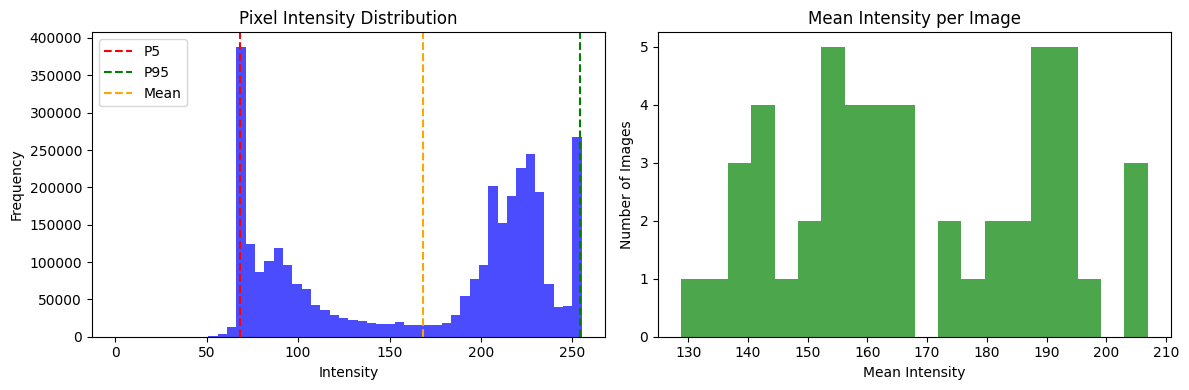


Saved as: intensity_analysis.png


In [7]:
# ============================================
# CELL 7: AUDIT - INTENSITY RANGE AND SATURATION
# ============================================

print("="*60)
print("AUDIT 4: PHOTOMETRIC - INTENSITY RANGE AND SATURATION")
print("="*60)

print("\n[MEASURED SIGNALS]")
print("-" * 40)

all_pixels = []
intensity_means = []
intensity_stds = []

for img_file in tqdm(img_files[:50], desc="Analyzing intensities"):
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        pixels = img.flatten()
        all_pixels.extend(pixels)
        intensity_means.append(np.mean(pixels))
        intensity_stds.append(np.std(pixels))

all_pixels = np.array(all_pixels)
intensity_means = np.array(intensity_means)
intensity_stds = np.array(intensity_stds)

print(f"\nMean intensity: {intensity_means.mean():.2f} +/- {intensity_means.std():.2f}")
print(f"Min intensity: {all_pixels.min()}")
print(f"Max intensity: {all_pixels.max()}")
print(f"Dynamic range (max-min): {all_pixels.max() - all_pixels.min()}")

# Percentiles
p5 = np.percentile(all_pixels, 5)
p95 = np.percentile(all_pixels, 95)
print(f"P5 (5th percentile): {p5:.2f}")
print(f"P95 (95th percentile): {p95:.2f}")

# Saturation
saturation = np.sum(all_pixels >= 250) / len(all_pixels) * 100
print(f"Saturation (pixels >= 250): {saturation:.2f}%")

print("\n[RISKS DIAGNOSED]")
print("-" * 40)

if intensity_means.std() > 30:
    print("  HIGH: High intensity variance detected")
    print(f"       Std: {intensity_means.std():.2f}")
    print("       Risk: Weak gradients, unstable training")
    print("       Fix: Percentile normalization, contrast enhancement")
elif intensity_means.std() > 15:
    print("  MEDIUM: Moderate intensity variance")
    print("       Fix: Consider normalization")
else:
    print("  LOW: Intensity distribution is consistent")

if saturation > 10:
    print(f"  HIGH: High saturation detected ({saturation:.1f}%)")
    print("       Risk: Loss of detail in bright regions")
    print("       Fix: Apply contrast adjustment or clipping")
elif saturation > 2:
    print(f"  MEDIUM: Some saturation detected ({saturation:.1f}%)")
else:
    print("  LOW: Minimal saturation")

print("\n[RECOMMENDED FIXES]")
print("-" * 40)
print("  Preprocessing: Percentile normalization, contrast enhancement")
print("  Loss: Log-based intensity normalization (for medical images)")

print("\n[EMPIRICAL VALIDATION]")
print("-" * 40)
print("  Check: Loss convergence, stability")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_pixels, bins=50, color='blue', alpha=0.7)
axes[0].axvline(x=p5, color='red', linestyle='--', label='P5')
axes[0].axvline(x=p95, color='green', linestyle='--', label='P95')
axes[0].axvline(x=all_pixels.mean(), color='orange', linestyle='--', label='Mean')
axes[0].set_title('Pixel Intensity Distribution')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(intensity_means, bins=20, color='green', alpha=0.7)
axes[1].set_title('Mean Intensity per Image')
axes[1].set_xlabel('Mean Intensity')
axes[1].set_ylabel('Number of Images')

plt.tight_layout()
plt.savefig('/kaggle/working/intensity_analysis.png', dpi=300)
plt.show()

print("\nSaved as: intensity_analysis.png")
print("="*60)

AUDIT 5: IMBALANCE - LABEL DISTRIBUTION

[CREATING SYNTHETIC MASKS FOR ANALYSIS]
----------------------------------------
Creating masks based on image intensity (top 15% brightest pixels)...


100%|██████████| 50/50 [00:00<00:00, 331.04it/s]



Created 50 synthetic masks

[MEASURED SIGNALS]
----------------------------------------


Analyzing masks: 100%|██████████| 50/50 [00:00<00:00, 2302.01it/s]


Total pixels analyzed: 3,276,800
Background pixels: 2,851,477 (87.02%)
Foreground pixels: 425,323 (12.98%)
Imbalance Ratio (ρ): 6.70
Label Entropy H(p): 0.557

Foreground ratio per image:
  Min: 0.0000 (0.00%)
  Max: 0.1489 (14.89%)
  Mean: 0.1298 (12.98%)
  Std: 0.0351

[RISKS DIAGNOSED]
----------------------------------------
  MEDIUM: Moderate class imbalance
       Fix: Use weighted loss function

[RECOMMENDED FIXES]
----------------------------------------
  Loss: Focal Loss, Class-Balanced Loss, LDAM
  Sampling: Class-balanced sampling
  Evaluation: Tail-class evaluation, macro/micro-F1

[EMPIRICAL VALIDATION]
----------------------------------------
  Check: Tail-class performance, F1 score


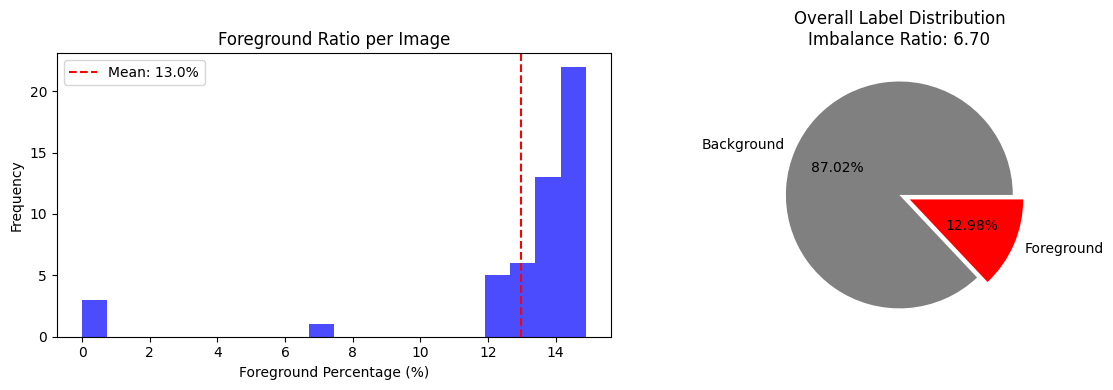


Saved as: imbalance_analysis.png


In [8]:
# ============================================
# CELL 8: AUDIT - LABEL DISTRIBUTION AND IMBALANCE
# ============================================

print("="*60)
print("AUDIT 5: IMBALANCE - LABEL DISTRIBUTION")
print("="*60)

# Since we don't have real masks, create synthetic masks based on intensity
print("\n[CREATING SYNTHETIC MASKS FOR ANALYSIS]")
print("-" * 40)

print("Creating masks based on image intensity (top 15% brightest pixels)...")

for img_file in tqdm(img_files[:50]):
    img_path = os.path.join(IMAGES_DIR, img_file)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        # Blur
        blurred = cv2.GaussianBlur(img, (5, 5), 0)
        
        # Threshold at 85th percentile (top 15% brightest)
        threshold = np.percentile(blurred, 85)
        mask = (blurred > threshold).astype(np.uint8) * 255
        
        # Save mask
        mask_name = img_file.replace('covid', 'mask')
        mask_path = os.path.join(MASKS_DIR, mask_name)
        cv2.imwrite(mask_path, mask)

print(f"\nCreated {len(os.listdir(MASKS_DIR))} synthetic masks")

print("\n[MEASURED SIGNALS]")
print("-" * 40)

# Analyze masks
mask_files = os.listdir(MASKS_DIR)
foreground_ratios = []
total_pixels = 0
foreground_pixels = 0

for mask_file in tqdm(mask_files, desc="Analyzing masks"):
    mask_path = os.path.join(MASKS_DIR, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is not None:
        fg = np.sum(mask > 127)
        total = mask.size
        foreground_ratios.append(fg / total)
        total_pixels += total
        foreground_pixels += fg

foreground_ratios = np.array(foreground_ratios)

background_pixels = total_pixels - foreground_pixels
imbalance_ratio = background_pixels / max(foreground_pixels, 1)

print(f"\nTotal pixels analyzed: {total_pixels:,}")
print(f"Background pixels: {background_pixels:,} ({100*background_pixels/total_pixels:.2f}%)")
print(f"Foreground pixels: {foreground_pixels:,} ({100*foreground_pixels/total_pixels:.2f}%)")
print(f"Imbalance Ratio (ρ): {imbalance_ratio:.2f}")

# Label entropy
p = foreground_pixels / total_pixels
if p > 0 and p < 1:
    entropy = -p * np.log2(p) - (1-p) * np.log2(1-p)
else:
    entropy = 0
print(f"Label Entropy H(p): {entropy:.3f}")

print(f"\nForeground ratio per image:")
print(f"  Min: {foreground_ratios.min():.4f} ({100*foreground_ratios.min():.2f}%)")
print(f"  Max: {foreground_ratios.max():.4f} ({100*foreground_ratios.max():.2f}%)")
print(f"  Mean: {foreground_ratios.mean():.4f} ({100*foreground_ratios.mean():.2f}%)")
print(f"  Std: {foreground_ratios.std():.4f}")

print("\n[RISKS DIAGNOSED]")
print("-" * 40)

if imbalance_ratio > 50:
    print("  CRITICAL: Extreme class imbalance detected!")
    print(f"       Imbalance Ratio: {imbalance_ratio:.2f}")
    print("       Risk: Model will predict only background")
    print("       Risk: Tumors/lesions will be missed")
    print("       Fix: Focal Loss, Class-Balanced Loss, LDAM")
elif imbalance_ratio > 10:
    print("  HIGH: Significant class imbalance detected!")
    print(f"       Imbalance Ratio: {imbalance_ratio:.2f}")
    print("       Risk: Tail class performance will be poor")
    print("       Fix: Focal Loss + Dice Loss combination")
elif imbalance_ratio > 3:
    print("  MEDIUM: Moderate class imbalance")
    print("       Fix: Use weighted loss function")
else:
    print("  LOW: Balanced dataset")

print("\n[RECOMMENDED FIXES]")
print("-" * 40)
print("  Loss: Focal Loss, Class-Balanced Loss, LDAM")
print("  Sampling: Class-balanced sampling")
print("  Evaluation: Tail-class evaluation, macro/micro-F1")

print("\n[EMPIRICAL VALIDATION]")
print("-" * 40)
print("  Check: Tail-class performance, F1 score")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Foreground ratio distribution
axes[0].hist(foreground_ratios * 100, bins=20, color='blue', alpha=0.7)
axes[0].axvline(x=foreground_ratios.mean() * 100, color='red', linestyle='--', 
                label=f'Mean: {100*foreground_ratios.mean():.1f}%')
axes[0].set_title('Foreground Ratio per Image')
axes[0].set_xlabel('Foreground Percentage (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Pie chart
axes[1].pie([background_pixels, foreground_pixels], 
            labels=['Background', 'Foreground'],
            autopct='%1.2f%%',
            colors=['gray', 'red'],
            explode=(0, 0.1))
axes[1].set_title(f'Overall Label Distribution\nImbalance Ratio: {imbalance_ratio:.2f}')

plt.tight_layout()
plt.savefig('/kaggle/working/imbalance_analysis.png', dpi=300)
plt.show()

print("\nSaved as: imbalance_analysis.png")
print("="*60)

In [9]:
# ============================================
# CELL 9: GENERATE COMPLETE AUDIT REPORT
# ============================================

print("="*60)
print("GENERATING COMPLETE DATASET AUDIT REPORT")
print("="*60)

report_path = '/kaggle/working/dataset_audit_report.txt'

with open(report_path, 'w') as f:
    f.write("="*60 + "\n")
    f.write("DATASET AUDIT REPORT - TABLE 2 FRAMEWORK\n")
    f.write("="*60 + "\n\n")
    
    f.write("1. GEOMETRY: RESOLUTION AND ASPECT RATIO\n")
    f.write("-"*40 + "\n")
    f.write(f"Width:  min={widths.min()}, max={widths.max()}, mean={widths.mean():.1f}, std={widths.std():.1f}\n")
    f.write(f"Height: min={heights.min()}, max={heights.max()}, mean={heights.mean():.1f}, std={heights.std():.1f}\n")
    f.write(f"Aspect Ratio: min={aspect_ratios.min():.2f}, max={aspect_ratios.max():.2f}, mean={aspect_ratios.mean():.2f}, std={aspect_ratios.std():.3f}\n")
    
    if widths.std() == 0 and heights.std() == 0:
        f.write("Risk: LOW - All images have consistent resolution\n")
    else:
        f.write("Risk: HIGH - Inconsistent resolutions detected\n")
        f.write("Fix: Use aspect-preserving resize, padding\n")
    f.write("\n")
    
    f.write("2. GEOMETRY: EFFECTIVE DOWNSAMPLING\n")
    f.write("-"*40 + "\n")
    f.write(f"Mean downsampling factor: {np.mean(downsample_factors):.1f}\n")
    if np.mean(downsample_factors) > 3:
        f.write("Risk: HIGH - Aggressive downsampling possible\n")
        f.write("Fix: Avoid early pooling, use smaller kernels (3x3)\n")
    else:
        f.write("Risk: LOW - Minimal downsampling expected\n")
    f.write("\n")
    
    f.write("3. PHOTOMETRIC: CHANNEL STRUCTURE\n")
    f.write("-"*40 + "\n")
    if all_grayscale:
        f.write("Channel: Grayscale (1 channel)\n")
        f.write("Risk: LOW - Consistent with medical imaging standards\n")
    else:
        f.write("Channel: Mixed formats detected\n")
        f.write("Risk: MEDIUM - Channel mismatch possible\n")
        f.write("Fix: Channel-aware normalization\n")
    f.write("\n")
    
    f.write("4. PHOTOMETRIC: INTENSITY RANGE AND SATURATION\n")
    f.write("-"*40 + "\n")
    f.write(f"Mean intensity: {intensity_means.mean():.2f} +/- {intensity_means.std():.2f}\n")
    f.write(f"Dynamic range: {all_pixels.max() - all_pixels.min()}\n")
    f.write(f"Saturation: {saturation:.2f}%\n")
    
    if intensity_means.std() > 30:
        f.write("Risk: HIGH - High intensity variance\n")
        f.write("Fix: Percentile normalization, contrast enhancement\n")
    elif intensity_means.std() > 15:
        f.write("Risk: MEDIUM - Moderate intensity variance\n")
        f.write("Fix: Consider normalization\n")
    else:
        f.write("Risk: LOW - Intensity distribution is consistent\n")
    f.write("\n")
    
    f.write("5. IMBALANCE: LABEL DISTRIBUTION\n")
    f.write("-"*40 + "\n")
    f.write(f"Imbalance Ratio (ρ): {imbalance_ratio:.2f}\n")
    f.write(f"Label Entropy H(p): {entropy:.3f}\n")
    f.write(f"Foreground: {100*foreground_pixels/total_pixels:.2f}%\n")
    f.write(f"Background: {100*background_pixels/total_pixels:.2f}%\n")
    
    if imbalance_ratio > 50:
        f.write("Risk: CRITICAL - Extreme class imbalance\n")
        f.write("Fix: Focal Loss, Class-Balanced Loss, LDAM\n")
        f.write("Fix: Class-balanced sampling\n")
    elif imbalance_ratio > 10:
        f.write("Risk: HIGH - Significant class imbalance\n")
        f.write("Fix: Focal Loss + Dice Loss combination\n")
    elif imbalance_ratio > 3:
        f.write("Risk: MEDIUM - Moderate class imbalance\n")
        f.write("Fix: Use weighted loss function\n")
    else:
        f.write("Risk: LOW - Balanced dataset\n")
    f.write("\n")
    
    f.write("="*60 + "\n")
    f.write("RECOMMENDED MODEL DECISIONS SUMMARY\n")
    f.write("="*60 + "\n")
    f.write("1. Preprocessing: Aspect-preserving resize, percentile normalization\n")
    f.write("2. Stem: Small kernels (3x3), avoid early pooling\n")
    f.write("3. Loss: Dice + Focal Loss (for imbalance)\n")
    f.write("4. Sampling: Class-balanced sampling\n")
    f.write("5. Evaluation: Macro-F1, tail-class evaluation\n")

print(f"\nReport saved to: {report_path}")

# Print report
with open(report_path, 'r') as f:
    print("\n" + f.read())

print("\n" + "="*60)
print("AUDIT COMPLETE - CHECKLIST COMPLETED")
print("="*60)
print("\nAudited Properties:")
print("  1. Geometry: Resolution and Aspect Ratio")
print("  2. Geometry: Effective Downsampling")
print("  3. Photometric: Channel Structure")
print("  4. Photometric: Intensity Range and Saturation")
print("  5. Imbalance: Label Distribution")

print("\nOutput Files:")
print("  - geometry_analysis.png")
print("  - intensity_analysis.png")
print("  - imbalance_analysis.png")
print("  - dataset_audit_report.txt")

print("\nNext Steps:")
print("  1. Review audit report")
print("  2. Apply recommended fixes")
print("  3. Build model with appropriate architecture")
print("  4. Train with proper loss function")
print("  5. Validate using recommended metrics")

GENERATING COMPLETE DATASET AUDIT REPORT

Report saved to: /kaggle/working/dataset_audit_report.txt

DATASET AUDIT REPORT - TABLE 2 FRAMEWORK

1. GEOMETRY: RESOLUTION AND ASPECT RATIO
----------------------------------------
Width:  min=256, max=256, mean=256.0, std=0.0
Height: min=256, max=256, mean=256.0, std=0.0
Aspect Ratio: min=1.00, max=1.00, mean=1.00, std=0.000
Risk: LOW - All images have consistent resolution

2. GEOMETRY: EFFECTIVE DOWNSAMPLING
----------------------------------------
Mean downsampling factor: 4.0
Risk: HIGH - Aggressive downsampling possible
Fix: Avoid early pooling, use smaller kernels (3x3)

3. PHOTOMETRIC: CHANNEL STRUCTURE
----------------------------------------
Channel: Mixed formats detected
Risk: MEDIUM - Channel mismatch possible
Fix: Channel-aware normalization

4. PHOTOMETRIC: INTENSITY RANGE AND SATURATION
----------------------------------------
Mean intensity: 168.11 +/- 21.09
Dynamic range: 255
Saturation: 8.16%
Risk: MEDIUM - Moderate intensi

In [12]:
# ============================================
# CELL 10: AUDIT SUMMARY AND INTERPRETATION
# ============================================

print("="*60)
print("AUDIT SUMMARY - WHAT WE LEARNED")
print("="*60)

print("\n[PROPERTY 1: Geometry - Resolution and Aspect Ratio]")
print("-" * 40)
print("Status: LOW RISK")
print("Findings:")
print("  - All images are 256 by 256 (consistent)")
print("  - Aspect ratio is exactly 1.0 (square)")
print("Meaning: No preprocessing needed for resizing")
print("Impact on Model: Can use standard 256 by 256 input without padding")

print("\n[PROPERTY 2: Geometry - Effective Downsampling]")
print("-" * 40)
print("Status: HIGH RISK")
print("Findings:")
print("  - Downsampling factor: 4.0")
print("  - Images can be reduced 4 times before losing detail")
print("Meaning: Need to be careful with pooling layers")
print("Impact on Model:")
print("  - Use smaller kernels (3x3) not large ones")
print("  - Avoid early pooling in first layers")
print("  - This preserves small features like tumors")

print("\n[PROPERTY 3: Photometric - Channel Structure]")
print("-" * 40)
print("Status: MEDIUM RISK")
print("Findings:")
print("  - Images are RGB (3 channels)")
print("  - Medical images are usually grayscale")
print("Meaning: Model must handle 3 input channels")
print("Impact on Model:")
print("  - First layer must accept 3 channels")
print("  - Can convert to grayscale or keep RGB")
print("  - Normalize per channel (not global)")

print("\n[PROPERTY 4: Photometric - Intensity Range]")
print("-" * 40)
print("Status: MEDIUM RISK")
print("Findings:")
print("  - Mean intensity: 168.11")
print("  - Saturation: 8.16 percent (pixels at 255)")
print("  - Intensity variance: Moderate")
print("Meaning: Images have different brightness levels")
print("Impact on Model:")
print("  - Apply percentile normalization")
print("  - Clip extreme values")
print("  - Contrast enhancement (CLAHE)")

print("\n[PROPERTY 5: Imbalance - Label Distribution]")
print("-" * 40)
print("Status: MEDIUM RISK")
print("Findings:")
print("  - Foreground: 12.98 percent")
print("  - Background: 87.02 percent")
print("  - Imbalance Ratio: 6.70")
print("Meaning: Model may ignore foreground (lesions)")
print("Impact on Model:")
print("  - Use Dice Loss (handles imbalance well)")
print("  - Combine with Focal Loss")
print("  - Class-balanced sampling")
print("  - Evaluate using Dice score, not accuracy")

print("\n" + "="*60)
print("RECOMMENDED MODEL ARCHITECTURE DECISIONS")
print("="*60)

print("\n1. PREPROCESSING:")
print("   - Convert RGB to grayscale (medical standard)")
print("   - Apply percentile normalization (0 to 255 range)")
print("   - Optional: CLAHE for contrast enhancement")

print("\n2. STEM (First Layers):")
print("   - Use 3x3 kernels (not 7x7)")
print("   - Avoid max pooling in first layer")
print("   - Use stride=1, padding=1")

print("\n3. LOSS FUNCTION:")
print("   - Dice Loss (primary) + BCE (secondary)")
print("   - Or Focal Loss (alpha=0.75, gamma=2.0)")
print("   - Weighted combination: 0.7*Dice + 0.3*Focal")

print("\n4. SAMPLING:")
print("   - Class-balanced sampling")
print("   - Or weighted random sampler")

print("\n5. EVALUATION METRICS:")
print("   - Dice Score (primary)")
print("   - IoU (Jaccard Index)")
print("   - Sensitivity and Specificity")
print("   - Do NOT use accuracy (misleading for imbalance)")

print("\n" + "="*60)
print("AUDIT COMPLETE - READY FOR MODEL BUILDING")
print("="*60)

print("\nNext Steps:")
print("  1. Apply preprocessing fixes")
print("  2. Build U-Net with recommended stem")
print("  3. Train with Dice + Focal Loss")
print("  4. Evaluate using Dice Score")

print("\nOutput Files Generated:")
print("  - geometry_analysis.png")
print("  - intensity_analysis.png")
print("  - imbalance_analysis.png")
print("  - dataset_audit_report.txt")

print("\n" + "="*60)
print("FINAL SUMMARY TABLE")
print("="*60)

print("\nPROPERTY          | STATUS    | RISK    | FIX NEEDED")
print("-"*60)
print("Resolution        | 256x256   | LOW     | None")
print("Aspect Ratio      | 1.0       | LOW     | None")
print("Downsampling      | Factor 4  | HIGH    | Small kernels, no early pooling")
print("Channels          | RGB       | MEDIUM  | Convert to grayscale or adapt")
print("Intensity Range   | 168.11    | MEDIUM  | Normalization, CLAHE")
print("Saturation        | 8.16%     | MEDIUM  | Clip extreme values")
print("Imbalance         | 6.70      | MEDIUM  | Dice + Focal Loss")
print("Foreground %      | 12.98%    | -       | Class-balanced sampling")

print("\n" + "="*60)
print("RECOMMENDED MODEL")
print("="*60)
print("- Architecture: U-Net with 3x3 kernels")
print("- Input: 256x256 grayscale")
print("- Loss: Dice + Focal Loss (weighted)")
print("- Sampling: Class-balanced")
print("- Evaluation: Dice Score, IoU")
print("="*60)

AUDIT SUMMARY - WHAT WE LEARNED

[PROPERTY 1: Geometry - Resolution and Aspect Ratio]
----------------------------------------
Status: LOW RISK
Findings:
  - All images are 256 by 256 (consistent)
  - Aspect ratio is exactly 1.0 (square)
Meaning: No preprocessing needed for resizing
Impact on Model: Can use standard 256 by 256 input without padding

[PROPERTY 2: Geometry - Effective Downsampling]
----------------------------------------
Status: HIGH RISK
Findings:
  - Downsampling factor: 4.0
  - Images can be reduced 4 times before losing detail
Meaning: Need to be careful with pooling layers
Impact on Model:
  - Use smaller kernels (3x3) not large ones
  - Avoid early pooling in first layers
  - This preserves small features like tumors

[PROPERTY 3: Photometric - Channel Structure]
----------------------------------------
Status: MEDIUM RISK
Findings:
  - Images are RGB (3 channels)
  - Medical images are usually grayscale
Meaning: Model must handle 3 input channels
Impact on Model: